# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [10]:
# ============================
# 📦 Essential Python Libraries
# ============================
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# 🖼️ Image Processing
# ============================
import cv2
from imutils import paths

# ============================
# 🧠 Machine Learning Utilities
# ============================
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report

# ============================
# 🤖 TensorFlow / Keras
# ============================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, SpatialDropout2D
)
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator, img_to_array, load_img, array_to_img
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical


In [11]:
dir_path = "C:/Users/rashm/OneDrive/Documents/2026-AIML/Dataset_Waste_Segregation/Dataset_Waste_Segregation/Dataset_Waste_Segregation/data/data"


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [12]:
# Create a function to load the raw images
target_size = (224, 224)

waste_labels = {
    "Cardboard":0,
    "Food_Waste":1,
    "Glass":2,
    "Metal":3,
    "Other":4,
    "Paper":5,
    "Plastic":6
}

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [13]:
# Get the images and their labels

def load_dataset(path):
  x = []
  labels = []
  image_paths = sorted(list(paths.list_images(path)))
  for image_path in image_paths:
    img = cv2.imread(image_path)
    img = cv2.resize(img, target_size)
    x.append(img)
    label = image_path.split(os.path.sep)[-2]
    labels.append(waste_labels[label])
  x, labels = shuffle(x, labels, random_state=42)
  input_shape = (np.array(x[0]).shape[1], np.array(x[0]).shape[1], 3)
  print("X shape: ", np.array(x).shape)
  print(f"Number of Labels: {len(np.unique(labels))} , Number of Observation: {len(labels)}")
  print("Input Shape: ", input_shape)
  return x, labels, input_shape

Perform any operations, if needed, on the images and labels to get them into the desired format.

In [14]:
x, labels, input_shape = load_dataset(dir_path)

X shape:  (7625, 224, 224, 3)
Number of Labels: 7 , Number of Observation: 7625
Input Shape:  (224, 224, 3)


### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

In [15]:
# Visualise Data Distribution

def viz_img(image_batch, labels, num_of_img):
  plt.figure(figsize=(10,10))
  for n in range(num_of_img):
    ax = plt.subplot(5,5,n+1)
    plt.imshow(image_batch[n])
    plt.title(np.array(list(waste_labels.keys()))[to_categorical(labels, num_classes=len(np.unique(labels)))[n] == 1][0].title())
    plt.axis("off")


#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

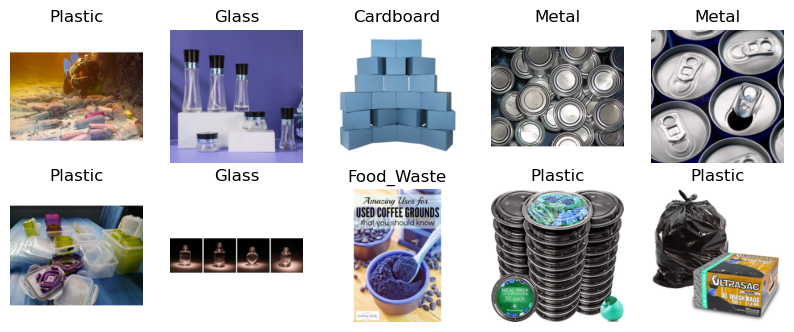

In [16]:
# Visualise Sample Images (across different labels)

viz_img(x, labels, 10)



#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [17]:
# Find the smallest and largest image dimensions from the data set

import cv2
import os
from imutils import paths

def find_image_dimension_range(path):
    widths = []
    heights = []

    for image_path in paths.list_images(path):
        img = cv2.imread(image_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

    print("Smallest width :", min(widths))
    print("Largest width  :", max(widths))
    print("Smallest height:", min(heights))
    print("Largest height :", max(heights))

    return (min(widths), max(widths), min(heights), max(heights))

find_image_dimension_range(dir_path)


Smallest width : 256
Largest width  : 256
Smallest height: 256
Largest height : 256


(256, 256, 256, 256)

In [18]:
# Resize the image dimensions

def load_dataset(path, target_size=(224, 224)):
    x = []
    labels = []

    for image_path in paths.list_images(path):
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize here
        img = cv2.resize(img, target_size)

        x.append(img)

        label = image_path.split(os.path.sep)[-2]
        labels.append(waste_labels[label])

    x, labels = shuffle(x, labels, random_state=42)
    input_shape = (target_size[0], target_size[1], 3)

    return x, labels, input_shape


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [19]:
# Encode the labels suitably
x, labels, input_shape = load_dataset(dir_path)

from tensorflow.keras.utils import to_categorical
labels = to_categorical(labels, num_classes=7)



### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [20]:
# Assign specified parts of the dataset to train and validation sets

from sklearn.model_selection import train_test_split
def split_data(x, labels):
    # First split: Train + Val and Test (90% - 10%)
    x_train_val, x_test, y_train_val, y_test = train_test_split(x, labels, test_size=0.1, random_state=42, stratify=labels)

    # Second split: Train and Val (from Train + Val) → 90% train, 10% val of total
    x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.1/0.9, random_state=42, stratify=y_train_val)
 
    print(f"Train: {len(x_train)}, Validation: {len(x_val)}, Test: {len(x_test)}")
    return x_train, x_val, x_test, y_train, y_val, y_test

In [21]:
x_train, x_val, x_test, y_train, y_val, y_test = split_data(x, labels)

Train: 6099, Validation: 763, Test: 763


In [22]:
# Split
x_train, x_val, x_test, y_train, y_val, y_test = split_data(x, labels)

# Convert to NumPy arrays
import numpy as np
x_train = np.array(x_train)
x_val   = np.array(x_val)
x_test  = np.array(x_test)

Train: 6099, Validation: 763, Test: 763


In [23]:
print(y_train.shape)


(6099, 7)


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [24]:
# Build and compile the model
def CNN_create_and_fit_model(x_train, x_val, x_test, y_train, y_val, y_test, summary=True, fit=True, epochs=30, batch_size=32):
    model = Sequential()

    # Model architecture
    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(x_train.shape[1], x_train.shape[2], 3), activation="relu"))
    model.add(MaxPooling2D(pool_size=2, strides=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2, strides=(2, 2)))

    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2, strides=(2, 2)))

    model.add(Flatten())

    model.add(Dense(units=64, activation="relu"))
    model.add(Dropout(rate=0.2))

    model.add(Dense(units=32, activation="relu"))
    model.add(Dropout(rate=0.2))

    model.add(Dense(units=7, activation="softmax"))

    # Compile the model
    model.compile(loss="categorical_crossentropy",
                  optimizer="adam",
                  metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), "acc"])

    # Callbacks
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=50, verbose=1, mode="min"), 
        ModelCheckpoint(filepath="mymodel1.h5", monitor="val_loss", mode="min", save_best_only=True, save_weights_only=False, verbose=1)
    ]

    if summary:
        model.summary()

    # Train the model
    if fit:
        history = model.fit(
            x_train, y_train,  # Training data and labels
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(x_val, y_val),  # Validation data and labels
            callbacks=callbacks,
            steps_per_epoch=len(x_train) // batch_size,
            validation_steps=len(x_val) // batch_size
        )

    return model, history



#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [25]:
import inspect
print(inspect.getsource(split_data))


def split_data(x, labels):
    # First split: Train + Val and Test (90% - 10%)
    x_train_val, x_test, y_train_val, y_test = train_test_split(x, labels, test_size=0.1, random_state=42, stratify=labels)

    # Second split: Train and Val (from Train + Val) → 90% train, 10% val of total
    x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.1/0.9, random_state=42, stratify=y_train_val)

    print(f"Train: {len(x_train)}, Validation: {len(x_val)}, Test: {len(x_test)}")
    return x_train, x_val, x_test, y_train, y_val, y_test



In [26]:
# Training
def CNN_create_and_fit_model(x_train, x_val, x_test, y_train, y_val, y_test, summary=True, fit=True, epochs=100, batch_size=32):
    model = Sequential()

    # Model architecture
    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same", input_shape=(x_train.shape[1], x_train.shape[2], 3), activation="relu"))
    model.add(MaxPooling2D(pool_size=2, strides=(2, 2)))

    model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2, strides=(2, 2)))

    model.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(MaxPooling2D(pool_size=2, strides=(2, 2)))

    model.add(Flatten())

    model.add(Dense(units=64, activation="relu"))
    model.add(Dropout(rate=0.2))

    model.add(Dense(units=32, activation="relu"))
    model.add(Dropout(rate=0.2))

    model.add(Dense(units=7, activation="softmax"))

    # Compile the model
    model.compile(loss="categorical_crossentropy",
                  optimizer="adam",
                  metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), "acc"])

    # Callbacks
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=50, verbose=1, mode="min"), 
        ModelCheckpoint(filepath="mymodel1.h5", monitor="val_loss", mode="min", save_best_only=True, save_weights_only=False, verbose=1)
    ]

    if summary:
        model.summary()

    # Train the model
    if fit:
        history = model.fit(
            x_train, y_train,  # Training data and labels
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(x_val, y_val),  # Validation data and labels
            callbacks=callbacks,
            steps_per_epoch=len(x_train) // batch_size,
            validation_steps=len(x_val) // batch_size
        )

    return model, history



In [27]:
model, history = CNN_create_and_fit_model(
    x_train, x_val, x_test,
    y_train, y_val, y_test,
    summary=True,
    fit=True,
    epochs=30,
    batch_size=32
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,645,863 (6.28 MB)

 Trainable params: 1,645,863 (6.28 MB)

 Non-trainable params: 0 (0.00 B)

...


Epoch 13: finished saving model to mymodel1.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - acc: 0.3938 - loss: 1.6089 - precision: 0.7265 - recall: 0.1285 - val_acc: 0.3614 - val_loss: 1.7230 - val_precision: 0.6489 - val_recall: 0.0829
Epoch 14/30
  1/190 ━━━━━━━━━━━━━━━━━━━━ 3:04 977ms/step - acc: 0.4211 - loss: 1.7475 - precision: 0.5000 - recall: 0.0526
Epoch 14: val_loss improved from 1.72297 to 1.72005, saving model to mymodel1.h5



Epoch 14: finished saving model to mymodel1.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - acc: 0.4211 - loss: 1.7475 - precision: 0.5000 - recall: 0.0526 - val_acc: 0.3628 - val_loss: 1.7200 - val_precision: 0.6559 - val_recall: 0.0829
Epoch 15/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.4290 - loss: 1.5340 - precision: 0.7676 - recall: 0.1777
Epoch 15: val_loss improved from 1.72005 to 1.70268, saving model to mymodel1.h5



Epoch 15: finished saving model to mymodel1.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - acc: 0.4400 - loss: 1.5049 - precision: 0.7698 - recall: 0.1936 - val_acc: 0.3709 - val_loss: 1.7027 - val_precision: 0.6337 - val_recall: 0.1481
Epoch 16/30
  1/190 ━━━━━━━━━━━━━━━━━━━━ 3:13 1s/step - acc: 0.5263 - loss: 1.4341 - precision: 0.5000 - recall: 0.1579
Epoch 16: val_loss improved from 1.70268 to 1.69357, saving model to mymodel1.h5



Epoch 16: finished saving model to mymodel1.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - acc: 0.5263 - loss: 1.4341 - precision: 0.5000 - recall: 0.1579 - val_acc: 0.3764 - val_loss: 1.6936 - val_precision: 0.6331 - val_recall: 0.1454
Epoch 17/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.4769 - loss: 1.3780 - precision: 0.8054 - recall: 0.2633
Epoch 17: val_loss did not improve from 1.69357
190/190 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - acc: 0.4696 - loss: 1.3939 - precision: 0.7910 - recall: 0.2609 - val_acc: 0.3764 - val_loss: 1.7241 - val_precision: 0.6519 - val_recall: 0.1196
Epoch 18/30
  1/190 ━━━━━━━━━━━━━━━━━━━━ 3:07 990ms/step - acc: 0.4737 - loss: 1.2515 - precision: 1.0000 - recall: 0.3158
Epoch 18: val_loss did not improve from 1.69357
190/190 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - acc: 0.4737 - loss: 1.2515 - precision: 1.0000 - recall: 0.3158 - val_acc: 0.3764 - val_loss: 1.7269 - val_precision: 0.6418 - val_recall: 0.1168
Epoch 19/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s


Epoch 21: finished saving model to mymodel1.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - acc: 0.5523 - loss: 1.2179 - precision: 0.8312 - recall: 0.3686 - val_acc: 0.4266 - val_loss: 1.6710 - val_precision: 0.6364 - val_recall: 0.2283
Epoch 22/30
  1/190 ━━━━━━━━━━━━━━━━━━━━ 3:04 977ms/step - acc: 0.6316 - loss: 0.9663 - precision: 0.8889 - recall: 0.4211
Epoch 22: val_loss did not improve from 1.67101
190/190 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - acc: 0.6316 - loss: 0.9663 - precision: 0.8889 - recall: 0.4211 - val_acc: 0.4280 - val_loss: 1.6821 - val_precision: 0.6283 - val_recall: 0.2296
Epoch 23/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.5985 - loss: 1.0900 - precision: 0.8633 - recall: 0.4330
Epoch 23: val_loss did not improve from 1.67101
190/190 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - acc: 0.5923 - loss: 1.0922 - precision: 0.8521 - recall: 0.4339 - val_acc: 0.4185 - val_loss: 1.7753 - val_precision: 0.5946 - val_recall: 0.2391
Epoch 24/30
  1/190 ━━━━━━━━━━━━━━━━━━━━ 3:

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

In [28]:
# Evaluate on the test set; display suitable metrics



In [29]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

def CNN_model_evaluate(model, x_test, y_test, history, waste_labels):
    # Evaluate model
    loss, precision, recall, acc = model.evaluate(x_test, y_test, batch_size=32)
    print("Test Accuracy: %.2f%%" % (100 * acc))
    print("Test Loss: %.2f" % loss)
    print("Test Precision: %.2f%%" % (100 * precision))
    print("Test Recall: %.2f%%" % (100 * recall))

    # Predict
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Classification Report
    target_names = [str(label) for label in waste_labels.values()]

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=target_names))

    # Plot Accuracy and Loss
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["acc"], color="r", label="Training Accuracy")
    plt.plot(history.history["val_acc"], color="b", label="Validation Accuracy")
    plt.legend(loc="lower right")
    plt.xlabel("Epoch", fontsize=16)
    plt.ylabel("Accuracy", fontsize=16)
    plt.ylim([0, 1])
    plt.title("Training and Validation Accuracy", fontsize=16)

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], color="r", label="Training Loss")
    plt.plot(history.history["val_loss"], color="b", label="Validation Loss")
    plt.legend(loc="upper right")
    plt.xlabel("Epoch", fontsize=16)
    plt.ylabel("Loss", fontsize=16)
    plt.ylim([0, max(max(history.history["loss"]), max(history.history["val_loss"]))])
    plt.title("Training and Validation Loss", fontsize=16)

    plt.tight_layout()
    plt.show()

    return y_true, y_pred


24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 499ms/step - acc: 0.4233 - loss: 2.0912 - precision: 0.5829 - recall: 0.2765
Test Accuracy: 42.33%
Test Loss: 2.09
Test Precision: 58.29%
Test Recall: 27.65%
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 513ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.35      0.20      0.26        54
           1       0.51      0.39      0.44       100
           2       0.20      0.09      0.13        75
           3       0.59      0.49      0.54       100
           4       0.49      0.21      0.29       101
           5       0.38      0.25      0.30       103
           6       0.40      0.74      0.52       230

    accuracy                           0.42       763
   macro avg       0.42      0.34      0.35       763
weighted avg       0.43      0.42      0.39       763



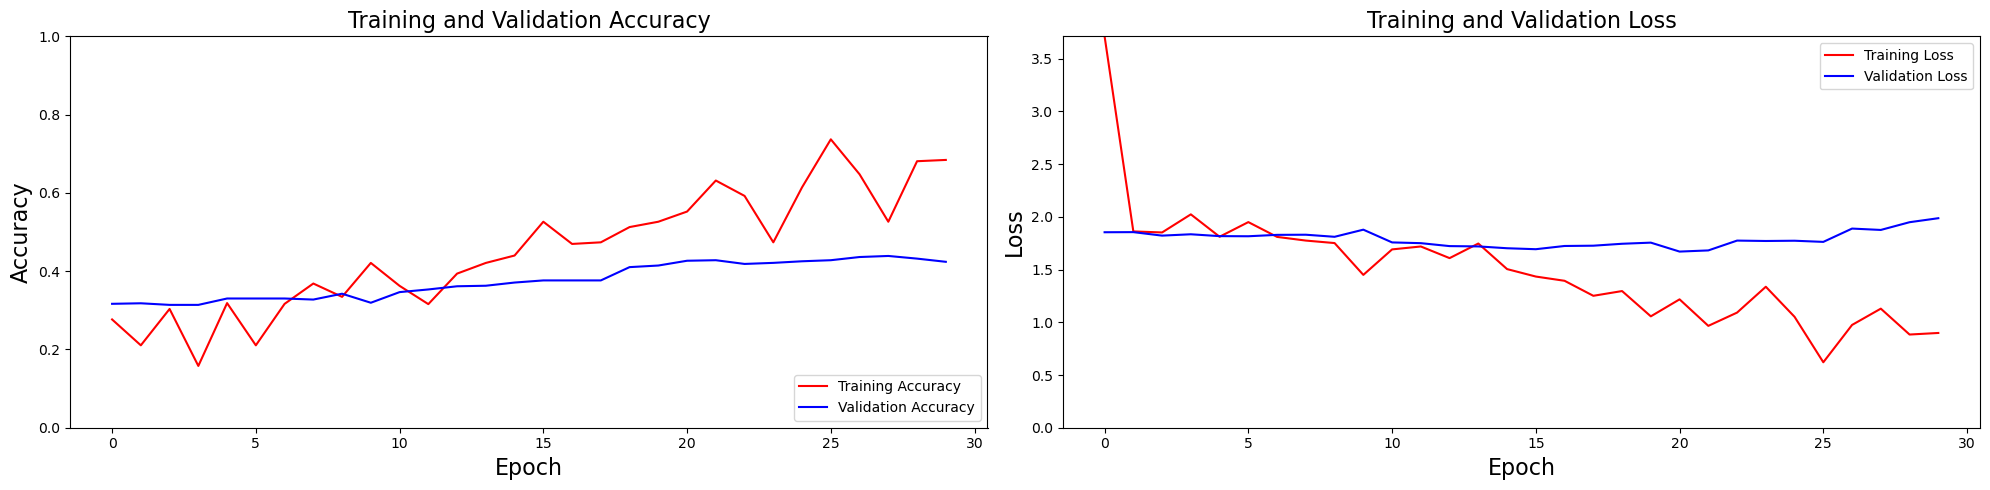

In [30]:
y_test, y_pred = CNN_model_evaluate(model, x_test, y_test, history, waste_labels)


## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [31]:
# Define augmentation steps to augment images



Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [32]:
# Create a function to augment the images




In [33]:
# Create the augmented training dataset



##### **4.1.2**

Train the model on the new augmented dataset.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step


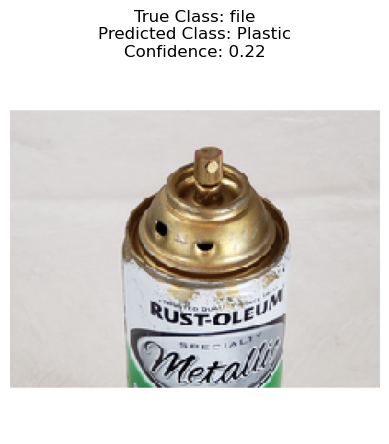

True Label: file
Predicted Label: Plastic


In [34]:
# Train the model using augmented images
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def CNN_model_test_random_image_with_true_label(model, test_folder, waste_labels, image_size=(224, 224)):
    # Get all image paths
    image_paths = [os.path.join(test_folder, img_name)
                   for img_name in os.listdir(test_folder)
                   if img_name.endswith(('.jpg', '.png', '.jpeg'))]

    if not image_paths:
        print("No images found in the test folder.")
        return None, None

    # Pick a random image
    img_path = random.choice(image_paths)
    filename = os.path.basename(img_path)

    # Extract true label from filename (e.g., "glass_01.jpg" → "glass")
    true_label = filename.split("_")[0].lower()

    # Load and preprocess image
    img = load_img(img_path, target_size=image_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    p = model.predict(img_array)
    predicted_class = np.argmax(p[0])
    predicted_label = waste_labels[predicted_class]
    confidence = np.max(p[0])

    # Display
    plt.axis("off")
    plt.imshow(img)
    plt.title(f"True Class: {true_label}\n"
              f"Predicted Class: {predicted_label}\n"
              f"Confidence: {confidence:.2f}")
    plt.show()

    return true_label, predicted_label

# Example usage
test_folder = "C:/Users/rashm/OneDrive/Documents/2026-AIML/Dataset_Waste_Segregation/test_images"
waste_labels = [
    "Cardboard",
    "Food_Waste",
    "Glass",
    "Metal",
    "Other",
    "Paper",
    "Plastic"
]


true_label, predicted_label = CNN_model_test_random_image_with_true_label(model, test_folder, waste_labels)
print(f"True Label: {true_label}")
print(f"Predicted Label: {predicted_label}")



In [35]:
import os
import numpy as np
import cv2

def save_test_images(x_test, y_test, class_names, output_dir="Segregated_Folder"):
    os.makedirs(output_dir, exist_ok=True)

    # If y_test is one-hot encoded, convert it to label indices
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_test = np.argmax(y_test, axis=1)

    for idx, (img, label_idx) in enumerate(zip(x_test, y_test)):
        # Rescale to 0–255 if normalized
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)

        # Convert RGB to BGR for OpenCV
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        # File name: e.g., paper_12.jpg
        class_name = class_names[label_idx]
        filename = f"{class_name}_{idx}.jpg"
        filepath = os.path.join(output_dir, filename)

        # Save image
        cv2.imwrite(filepath, img_bgr)

    print(f"✅ Saved {len(x_test)} images to '{output_dir}'.")

 


In [36]:
class_names = [
    "Cardboard",
    "Food_Waste",
    "Glass",
    "Metal",
    "Other",
    "Paper",
    "Plastic"
]

save_test_images(x_test, y_test, class_names)

✅ Saved 763 images to 'Segregated_Folder'.


## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results